 <br /><h1 style="font-family:Impact,Arial;font-size:70px;">Active Transport Congestion Analysis: Identifying Actionable Pedestrian and Cyclist Insights</h1>
<h2 style="font-family:Arial;">Group 2</h2>
<h2 style="font-family:Arial;">
<p> * Jensen Jones - 24935900</p>
<p> * Aiden Hemaridis-Smith - TODO</p>
<p> * Matthew Crowe - TODO</p>
</h2>
<p><small> 37373 Programming for Data Analysis</small></p>
<p><small><font color=MediumVioletRed>Autumn 2025</font></small>
</p>
<hr style="height:5px;border:none;color:#333;background-color:#333;" />

 # Abstract

Write a short (no more than 7 lines) summary of your project's topic and main goals.

 This project analyses pedestrian and cyclist transport activity data to identify patterns in movement and potential areas of congestion within urban transport corridors. The dataset contains activity counts collected at multiple locations over time, allowing for detailed analysis of transport demand and usage trends. Python was used to process, clean, and analyse the data efficiently, with visualisations used to communicate key findings. The study aims to determine which locations experience consistently high activity levels and whether these patterns may indicate the need for infrastructure upgrades or improved traffic management strategies. The findings demonstrate how transport activity data can support data-driven urban planning and improve active transport efficiency.

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>1. Motivation and Contribution</h1>

Write a detailed description of the problem and the original goal(s) of the study. Explain why you were interested in this topic and the type of insight you were hoping to get from the data.

<b>Explain how your group worked together for this project, and contributions of each member in the group (single line for each group member).</b>

 As cities continue to grow and place more focus on sustainable transport, understanding pedestrian and cyclist movement patterns has become increasingly important. Congestion within active transport corridors can reduce efficiency, accessibility, and overall safety for commuters. As cities continue to encourage active transport methods such as walking and cycling, there is a greater need for infrastructure and traffic management systems that can effectively support demand.

The motivation for this project is to investigate how transport activity data can be used to identify areas experiencing high levels of pedestrian and cyclist congestion. By analysing patterns within the dataset, the project aims to determine whether certain locations may benefit from infrastructure upgrades or adjustments to traffic management systems, such as crossing signal timing or pathway capacity improvements.

This project contributes by applying data analysis techniques to real-world transport activity data and interpreting the findings within the context of urban planning and transport engineering. Rather than simply identifying trends, the study focuses on how the results could be used to support evidence-based decision-making for improving transport efficiency and reducing congestion within active transport networks.

Our group worked together on this project by distributing work evenly amongst each other, as well as taking parts that we as individuals are most interested in:
<P>Jensen: Data Preparation, Data exploration [4.1 - 4.4],
<P>Aiden:
<P>Matthew: Abstract, Motivation and Contribution,

TODO fill in the above ^^ & delete all the scaffold what to do text


 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>2. The Data</h1>
A clear description of the dataset(s) origin and a discussion of why it was chosen, as well as any restriction regarding the use, dissemination or modification of the data.

Note that wherever possible you should provide a link to the <b>unmodified, raw</b> data set.


 The dataset used in this project consists of pedestrian and cyclist transport activity count data collected across multiple locations. The data includes information such as count location identifiers, geographical coordinates, activity classifications (pedestrian or cyclist), timestamps, and activity counts recorded within five-minute intervals.

This dataset was selected because it provides a detailed and realistic representation of transport activity within urban environments. The high-frequency recording intervals allow for detailed analysis of peak usage periods and congestion patterns across different locations and times of day. Additionally, the dataset enables comparisons between pedestrian and cyclist activity, providing broader insight into active transport behaviour.

The data is suitable for investigating transport demand and identifying locations that may require improved infrastructure or traffic management strategies. By analysing changes in activity levels over time, the project can identify patterns associated with peak commuting periods and consistently high-demand transport corridors.

However, several limitations exist within the dataset. The data does not include contextual factors such as weather conditions, public events, road closures, or nearby construction activity, all of which may influence transport activity levels. Additionally, the dataset records activity counts only and does not directly measure congestion severity, travel speed, or infrastructure quality. Despite these limitations, the dataset remains appropriate for identifying general transport activity trends and supporting data-driven recommendations.

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>3. Data Preparation</h1>

Code and comments on how the raw data is put in a usable form (i.e., how you go from the raw data set(s) to the dataframe you are using for the analysis).

<b>Create as many code, markdown and raw cells as needed</b>

<b>Ensure you use appropriate markdown cells to explain what you are doing and why</b>

 We begin our **data preparation** by downloading the dataset as a zip archive containing 4 CSV files, one per quarter of 2025. Rather than downloading each file manually, we fetch the zip programmatically to keep the notebook self-contained and reproducible. Each file is:

1. Read into its own temporary dataframe
2. Assigned a `quarter` column parsed from the filename, so we retain which quarter each row belongs to after concatenation
3. Appended to `dfs`, our list of quarterly dataframes

Once all four quarters are loaded, they are concatenated into a single dataframe `df` for analysis.

 We include all four quarters to maximise our sample size for more reliable findings, to capture any seasonal variation in transport activity across the year, and to avoid bias that could arise from analysing a single quarter in isolation.

In [1]:
import pandas as pd

import requests
import io
import zipfile

# This zip contains 4 separate csv files, one per quarter of 2025
# We will concatenate this into one dataframe
url = "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2025.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    dfs = [] # list of each dataframe (each quarter as its own df)
    for name in z.namelist():
        if name.endswith(".csv"):
            print("Reading in file:", name)

            temp = pd.read_csv(z.open(name))
            mainName = name.replace(".csv", "") # without trailing file type
            quarter = mainName.split("-")[-1] # Take just the quarter
            print("\tQuarter:", quarter)
            temp["quarter"] = int(quarter)

            dfs.append(temp)

    df: pd.DataFrame = pd.concat(dfs, ignore_index=True) # concatenate the df's together

Reading in file: TransportActivityCount_2025-3.csv
	Quarter: 3
Reading in file: TransportActivityCount_2025-4.csv
	Quarter: 4
Reading in file: TransportActivityCount_2025-1.csv
	Quarter: 1
Reading in file: TransportActivityCount_2025-2.csv
	Quarter: 2


Part of data preparation includes converting datatypes to a more usable type, as well as handling NA values. First we will check the current status of these conditions in the dataframe:

In [2]:
print(f"Total nulls: {df.isnull().sum().sum()} / {df.size} cells\n")

print(df.dtypes)

Total nulls: 0 / 63942208 cells

countLocationId         int64
countlineName          object
countlineDirection     object
CountLocationLat      float64
CountLocationLong     float64
from                   object
to                     object
class                  object
count                   int64
year                    int64
quarter                 int64
dtype: object


Our dataset is clean and has no null values, we don't have to do anything here.<br>
We will however apply the following type conversions to prepare the data for analysis:
- `from` and `to` are parsed into datetime objects
- `class` and `countlineDirection` are converted to categorical dtype, reducing memory usage and improving groupby performance across the 5.8M row dataset

In [3]:
df["from"] = pd.to_datetime(df["from"])
df["to"] = pd.to_datetime(df["to"])
df["class"] = df["class"].astype("category")
df["countlineDirection"] = df["countlineDirection"].astype("category")

print(df.dtypes)

countLocationId                     int64
countlineName                      object
countlineDirection               category
CountLocationLat                  float64
CountLocationLong                 float64
from                  datetime64[ns, UTC]
to                    datetime64[ns, UTC]
class                            category
count                               int64
year                                int64
quarter                             int64
dtype: object


We will also add some extra columns that will be used in data exploration:

In [4]:
df["month"] = df["from"].dt.month # add months to df
df["day_of_week"] = df["from"].dt.day_name().astype("category") # add day of week

While the full dataset includes multiple transport modes (motor vehicles, pedestrians, cyclists, etc.), the primary objective of this study is to analyse active transport congestion patterns, specifically for pedestrians and cyclists.

To align the dataset with this objective, we create a filtered subset containing only pedestrian and cyclist observations (`df_focused`). This ensures that subsequent analysis directly reflects active transport demand without interference from motor vehicle traffic patterns.

Importantly, the full dataset (`df`) is retained for contextual comparison where necessary

In [5]:
df_focused = df[df["class"].isin(["pedestrian", "cyclist"])].copy()
df_focused["class"] = df_focused["class"].cat.remove_unused_categories()
print(df_focused["class"].value_counts())

class
pedestrian    2182951
cyclist       1478495
Name: count, dtype: int64


<hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>4. Exploratory data analysis</h1>

This is the main part of the project. Include code, plots, and detailed explanation of your analysis of the data. Be sure to include enough detail so that anyone can follow and understand what you are doing.

<b>Create as many code, markdown and raw cells as needed</b>

### 4.1 Analysing Locations

We first check how many unique count locations exist in the dataset before ranking them by activity.

In [6]:
print(f"Unique count locations IDs: {df['countLocationId'].nunique()}")
print(f"Unique count line names: {df['countlineName'].nunique()}")

Unique count locations IDs: 85
Unique count line names: 83


We see that 2 names are shared across multiple location IDs. Lets view these:

In [7]:
# Find names that have more than one location ID
duplicated_names = (
    df.groupby("countlineName")["countLocationId"]
    .nunique()
    .sort_values(ascending=False)
)

print(duplicated_names[duplicated_names > 1])

countlineName
S19_BoathouseDr_path_clm01          2
S27_AlbertSt_corssing_west_bn003    2
Name: countLocationId, dtype: int64


Two location names (`S19_BoathouseDr_path_clm01` and `S27_AlbertSt_corssing_west_bn003`) each have two associated sensor IDs.<br>
This could likely be because of directional sensors at the same physical location or two sensors on the same street but different locations. Lets determine why:

In [8]:
# Check to see if they have the same countlineDirection
display(df[df["countlineName"].isin(["S19_BoathouseDr_path_clm01", "S27_AlbertSt_corssing_west_bn003"])][["countlineName", "countLocationId", "countlineDirection"]].drop_duplicates())

# Check to see if they have the same latitude and longitude
display(df[df["countlineName"].isin(["S19_BoathouseDr_path_clm01", "S27_AlbertSt_corssing_west_bn003"])][["countlineName", "countLocationId", "CountLocationLat", "CountLocationLong"]].drop_duplicates())


,countlineName,countLocationId,countlineDirection
1984,S19_BoathouseDr_path_clm01,56085,CLOCKWISE_AND_ANTICLOCKWISE
2003,S19_BoathouseDr_path_clm01,56068,CLOCKWISE_AND_ANTICLOCKWISE
1407904,S27_AlbertSt_corssing_west_bn003,58104,CLOCKWISE_AND_ANTICLOCKWISE
1407973,S27_AlbertSt_corssing_west_bn003,58102,CLOCKWISE_AND_ANTICLOCKWISE


,countlineName,countLocationId,CountLocationLat,CountLocationLong
1984,S19_BoathouseDr_path_clm01,56085,-37.820011,144.971695
2003,S19_BoathouseDr_path_clm01,56068,-37.820011,144.971695
1407904,S27_AlbertSt_corssing_west_bn003,58104,-37.810513,144.983551
1407973,S27_AlbertSt_corssing_west_bn003,58102,-37.810513,144.983551


Checking the direction and coordinates of both sensors at each duplicated location confirms they share identical coordinates and direction values, indicating these are duplicate sensor registrations at the same physical location rather than distinct sensors. We will now confirm this in code, by checking whether identical entries exist, where each field aside from the location ID are the same, which would indicate a duplicate entry, and then removing one of these.

In [9]:
# Check if duplicate location IDs have identical readings
duplicate_names = ["S19_BoathouseDr_path_clm01", "S27_AlbertSt_corssing_west_bn003"]
dupes = df[df["countlineName"].isin(duplicate_names)]

# If truly duplicate, rows with different countLocationId but same everything else should match
cols = [c for c in df.columns if c != "countLocationId"]
fully_duplicated = dupes[dupes.duplicated(subset=cols, keep=False)]
print(f"Rows with identical readings across duplicate sensor IDs: {len(fully_duplicated)}")
print(f"Out of total rows for these locations: {len(dupes)}")

df = df.drop_duplicates(subset=cols)
print(f"Rows after deduplication: {len(df)}")

Rows with identical readings across duplicate sensor IDs: 3892
Out of total rows for these locations: 69934
Rows after deduplication: 5810982


We have now removed these duplicated rows.

With 85 unique count locations across the network (83 unique names, with 2 names consolidated after removing duplicate sensor registrations), we want to identify which corridors experience the highest total activity. We first look into the top 15 most active corridors on our focused dataset. This is directly relevant to our goal of identifying areas that may benefit from infrastructure improvements.

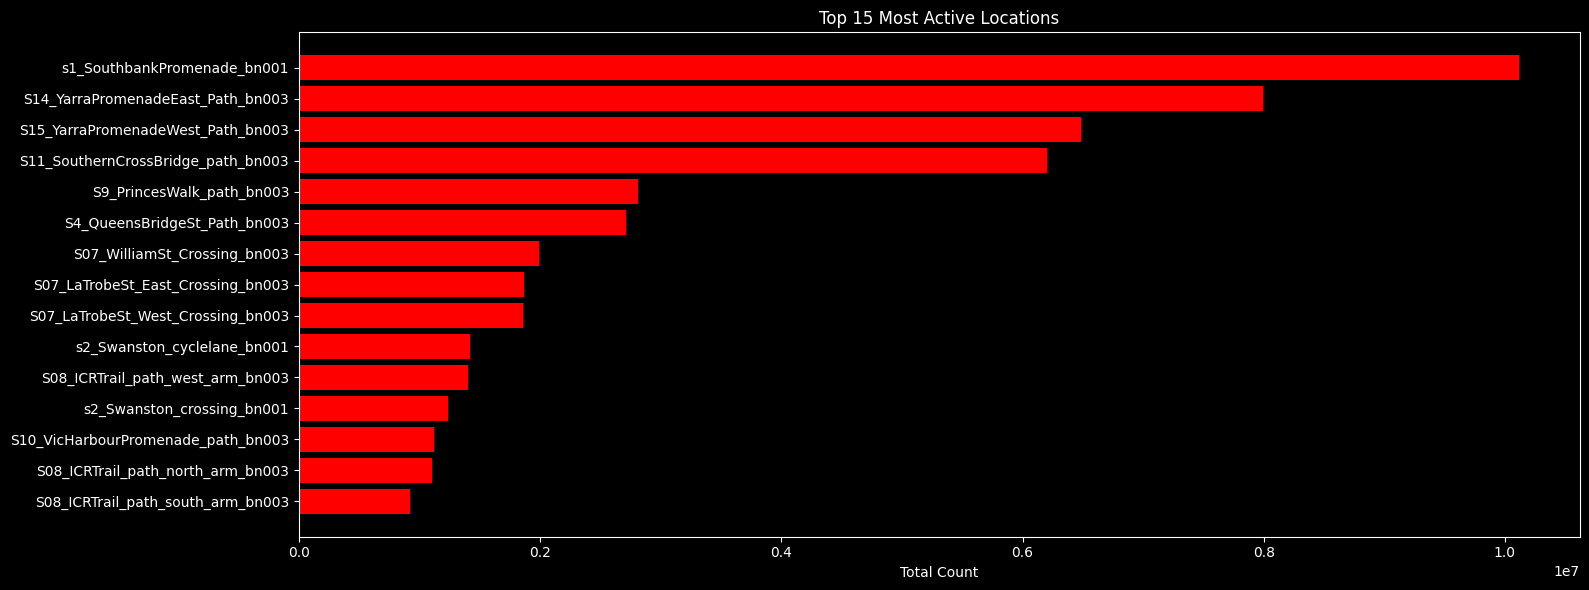

In [10]:
import matplotlib.pyplot as plt
plt.style.use("dark_background") # cooler plots

# Total activity per location
location_totals = (
    df_focused.groupby("countlineName")["count"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(figsize=(16, 6))

# Top 15
top15 = location_totals.head(15)
axes.barh(top15["countlineName"], top15["count"], color="red")
axes.set_title("Top 15 Most Active Locations")
axes.set_xlabel("Total Count")
axes.set_ylabel("")
axes.invert_yaxis()

plt.tight_layout()
plt.show()

### 4.2 Transport Over Time

We now investigate how transport activity varies across time, specifically by hour of day and day of week. This allows us to identify peak demand periods and understand commuting patterns for `pedestrians` and `cyclists`. Given our specific focus on producing usable outcomes for uban planning for `pedestrian` and `cyclists`, we will here group together any vehicle that isn't `pedestrian` or `cyclist` as `other`.

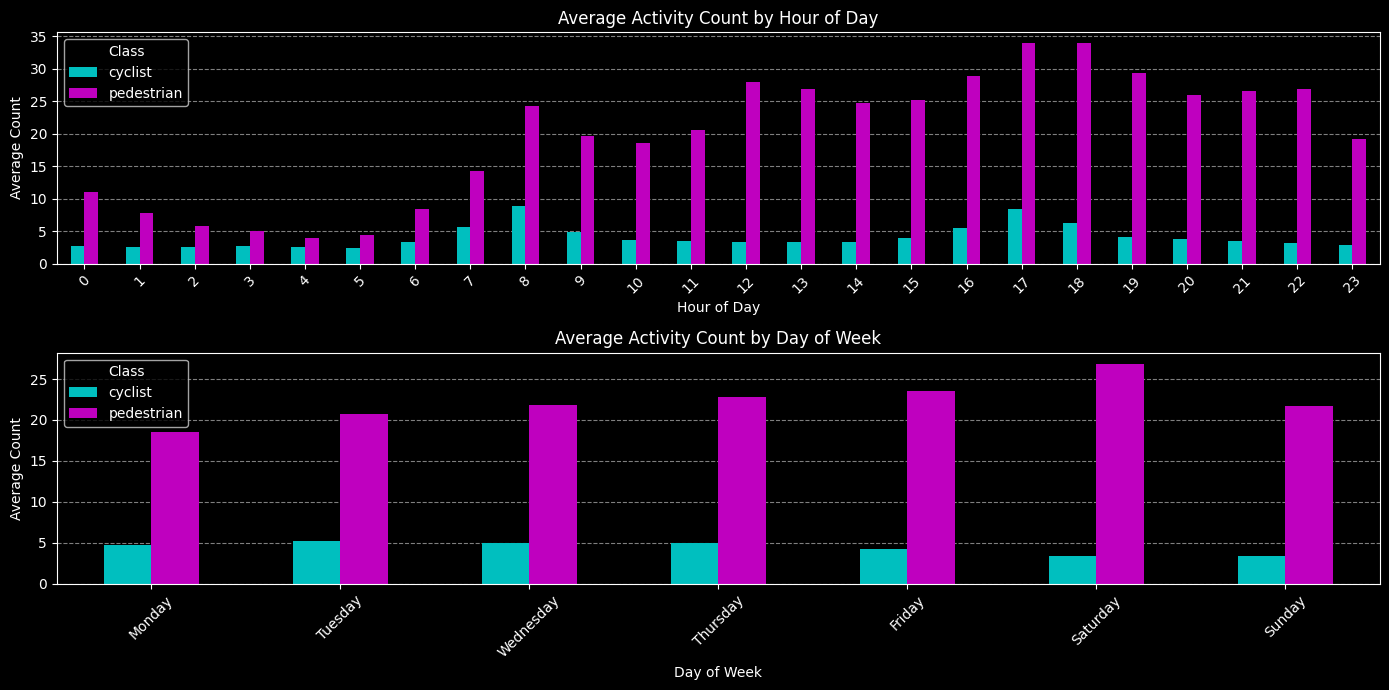

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

colors = ["c", "m"]

# Hour of day
hourly = df_focused.groupby([df_focused["from"].dt.hour, "class"], observed=True)["count"].mean().unstack()
hourly.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Average Activity Count by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Class")
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[0].set_axisbelow(True)


# Day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df_focused.groupby(["day_of_week", "class"], observed=True)["count"].mean().unstack()
daily = daily.reindex(day_order)
daily.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Average Activity Count by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Class")
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)
plt.tight_layout()
plt.show()

The hourly distribution reveals a clear **evening peak for pedestrians at 17:00–18:00**, consistent with end-of-day commuting, with a secondary peak at midday likely reflecting lunch activity. Notably, there is no strong morning commute spike for pedestrians, activity builds gradually from 6am, suggesting these corridors serve a broader mix of trip purposes beyond strict commuting.

Cyclists show a more pronounced **dual peak at 08:00 and 17:00**, strongly consistent with work commute behaviour. This also explains why cyclist counts are relatively low during midday hours compared to other vehicles, which remain steadier throughout the day as cars continue to be used for work-related business regardless of time.

The day-of-week chart reveals an interesting inverse relationship between cyclists and other vehicles on weekends: **cyclist activity drops on Saturday and Sunday while other vehicle activity rises**. Rather than reflecting two distinct groups of people, this may suggest that many commuters are multi-modal — cycling to work on weekdays and switching to driving on weekends. This would explain why the two classes move in opposite directions rather than independently.

Pedestrian activity peaks on **Saturday**, again suggesting these corridors serve a significant recreational function beyond weekday commuting.

### 4.4 Identifying High-Demand Corridors

The core objective of this study is to identify locations experiencing consistently high pedestrian and cyclist activity, locations that may be candidates for infrastructure upgrades or improved traffic management. A location that is simply busy on one day is less concerning than one that is persistently under high demand.

We approach this in four stages:

1. Absolute demand - which corridors carry the most total active transport volume (seen in activity 4.1)?
2. Consistency - which corridors remain high-demand across all time periods, not just occasional spikes?
3. Peak congestion windows - for the highest-demand corridors, when exactly does demand concentrate, and how severe is it?
4. Correlation between cyclist and pedestrian usage - which corridors are high in both, low in both, or a mix?

The absolute demand or total transport volume of pedestrians and cyclists through each corridor in 2025 can be seen sorted in descending in section 4.1. Clearly the top 4 locations are well higher in terms of total volume.

For the remainder of this section, we will focus on analysing the top 10 total volume locations:

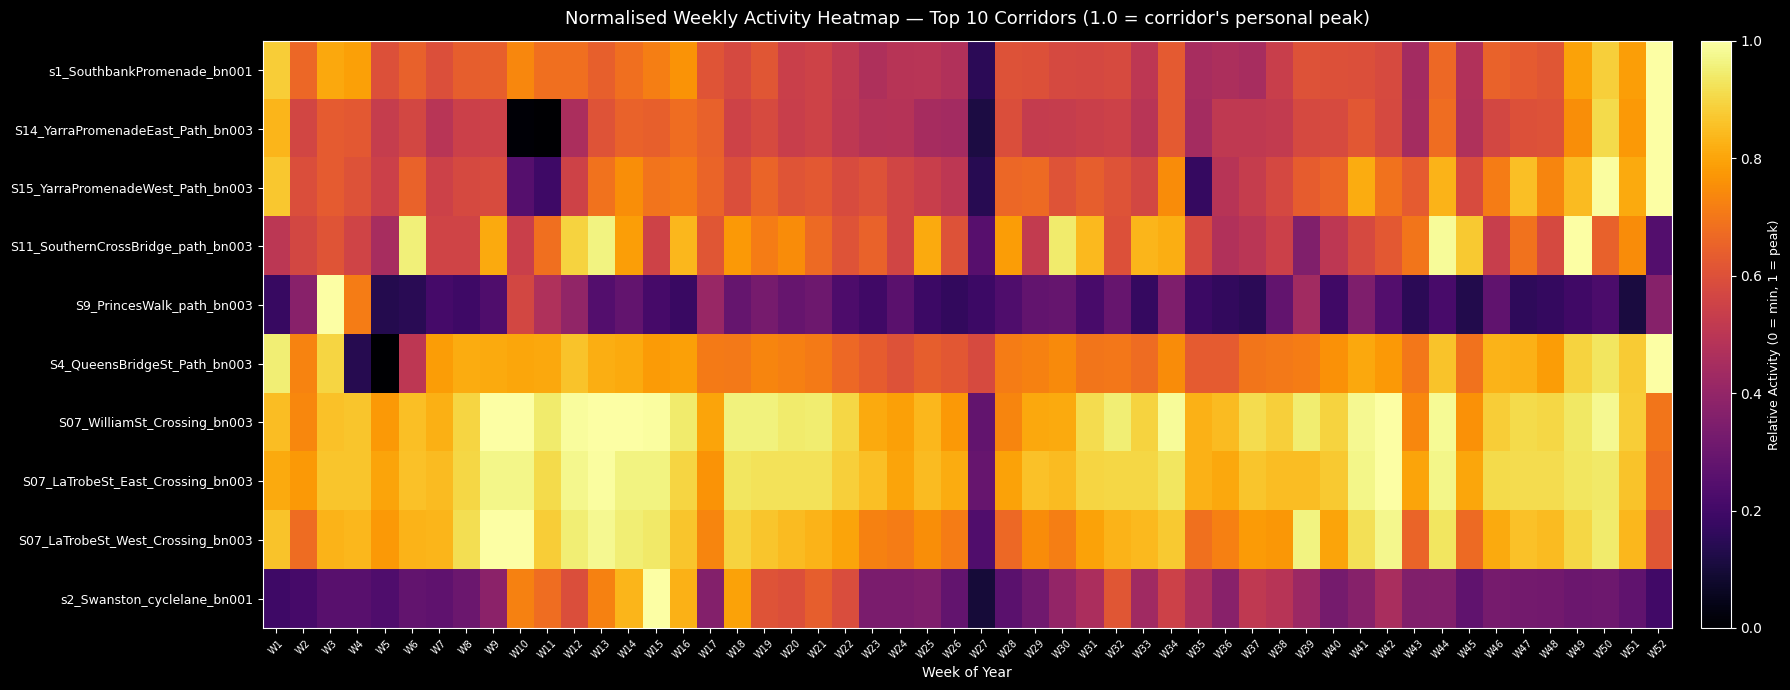

In [12]:
# Define top 10 corridors by total active transport volume
corridor_totals = (
    df_focused.groupby("countlineName")["count"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"count": "total_activity"})
)

TOP_N = 10
top_corridors = corridor_totals.head(TOP_N)["countlineName"].tolist()

# Weekly totals per corridor (top 10 only)
df_focused["week"] = df_focused["from"].dt.isocalendar().week.astype(int)

weekly = (
    df_focused[df_focused["countlineName"].isin(top_corridors)]
    .groupby(["countlineName", "week"])["count"]
    .sum()
    .unstack(fill_value=0)
)

# Normalise each row to its own max so corridors are visually comparable
weekly_norm = weekly.div(weekly.max(axis=1), axis=0)

# Sort rows by mean normalised activity (busiest at top)
weekly_norm = weekly_norm.loc[top_corridors]

fig, ax = plt.subplots(figsize=(18, 7))

im = ax.imshow(weekly_norm.values, aspect="auto", cmap="inferno", vmin=0, vmax=1)

ax.set_yticks(range(len(weekly_norm.index)))
ax.set_yticklabels(weekly_norm.index, fontsize=9)
ax.set_xticks(range(len(weekly_norm.columns)))
ax.set_xticklabels([f"W{w}" for w in weekly_norm.columns], fontsize=7, rotation=45)

ax.set_title("Normalised Weekly Activity Heatmap — Top 10 Corridors (1.0 = corridor's personal peak)", fontsize=13, pad=12)
ax.set_xlabel("Week of Year")

cbar = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Relative Activity (0 = min, 1 = peak)", fontsize=9)

plt.tight_layout()
plt.show()

The heatmap reveals two distinct corridor archetypes:

- Consistently high-demand corridors (near-uniform bright rows) - these locations sustain high activity levels week after week, suggesting structural demand driven by commuters or well-established recreational routes. These are the strongest candidates for infrastructure capacity upgrades.
- Spike-dominant corridors (mostly dark with isolated bright patches) - high total volume may be driven by a small number of exceptional weeks (events, holidays, favourable weather). These corridors may benefit more from event-responsive traffic management than permanent infrastructure investment.

To make this distinction quantitative, we compute the coefficient of variation (CV) for each corridor's weekly activity a lower CV indicates more consistent demand.

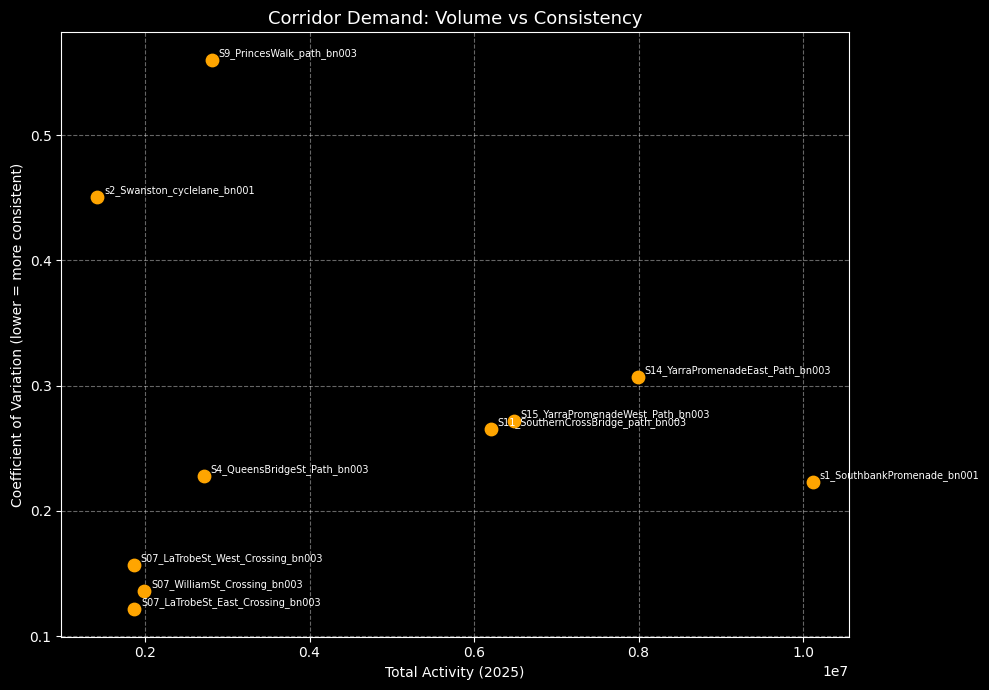

Priority corridors (high demand, consistent):
                     countlineName  total_activity       cv
       s1_SouthbankPromenade_bn001        10117242 0.222920
S11_SouthernCrossBridge_path_bn003         6202380 0.264977
 S15_YarraPromenadeWest_Path_bn003         6483142 0.271740
 S14_YarraPromenadeEast_Path_bn003         7990261 0.306668
         S9_PrincesWalk_path_bn003         2812096 0.560129


In [13]:
# Coefficient of Variation (CV) = std / mean — lower means more consistent weekly demand
cv = weekly.std(axis=1) / weekly.mean(axis=1)
cv = cv.rename("cv").reset_index()
cv = cv.merge(corridor_totals, on="countlineName")

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    cv["total_activity"],
    cv["cv"],
    color="orange",
    s=80,
    zorder=3
)

for _, row in cv.iterrows():
    ax.annotate(row["countlineName"], (row["total_activity"], row["cv"]),
                fontsize=7, xytext=(5, 3), textcoords="offset points", color="white")

ax.set_xlabel("Total Activity (2025)")
ax.set_ylabel("Coefficient of Variation (lower = more consistent)")
ax.set_title("Corridor Demand: Volume vs Consistency", fontsize=13)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print the priority candidates: high volume AND low CV
print("Priority corridors (high demand, consistent):")
priority = cv[cv["total_activity"] > cv["total_activity"].median()]
priority = priority.sort_values("cv").head(5)
print(priority[["countlineName", "total_activity", "cv"]].to_string(index=False))

### Interpreting the Scatter Plot

Each corridor is plotted by two things:
- X-axis: total activity across 2025 (further right = busier overall)
- Y-axis: Coefficient of Variation of weekly counts (lower = more consistently busy, not just occasionally)

The sweet spot for infrastructure candidates is bottom-right: high volume (actually being used) and low CV (consistently being used) together.

---

**Bottom-right (high volume, consistent):** Strongest candidates. `s1_SouthbankPromenade_bn001` stands out most with the highest volume in the dataset and one of the lowest CVs. `S14_YarraPromenadeEast_Path_bn003` follows closely, both showing sustained demand consistent with daily commuter use.

**Bottom-left (lower volume, consistent):** Worth watching. The La Trobe St crossings have very low CVs meaning they show up reliably every week, even if total counts are modest. Could become bottlenecks as cycling grows.

**Top-right (high volume, inconsistent):** Investigate further before committing to infrastructure. High totals here may be driven by a handful of busy weeks rather than everyday congestion.

**Top-left (low volume, erratic):** `59_PrincessWalk_path_bn003` has a CV of ~0.56, by far the highest. Likely capturing event crowds on Swanston St rather than routine transport. Not a good infrastructure candidate on volume alone.

So far we've looked at combined active transport volume.

The hourly analysis in 4.2 revealed that cyclists follow a strict dual commute peak (08:00 and 17:00) while pedestrians are more spread throughout the day. That analysis was however aggregated across all corridors. The critical infrastructure question is whether these peaks coincide at the corridor level, showing a conflict for space in the corridor between transport modes.

For each of the top 10 corridors, we compute the average hourly count per class, then define the **conflict score** at each hour as the minimum of the two normalised activity levels. A high minimum means both modes are simultaneously busy (neither is off-peak at that hour). We then sum this across all hours to produce a single per-corridor conflict index.

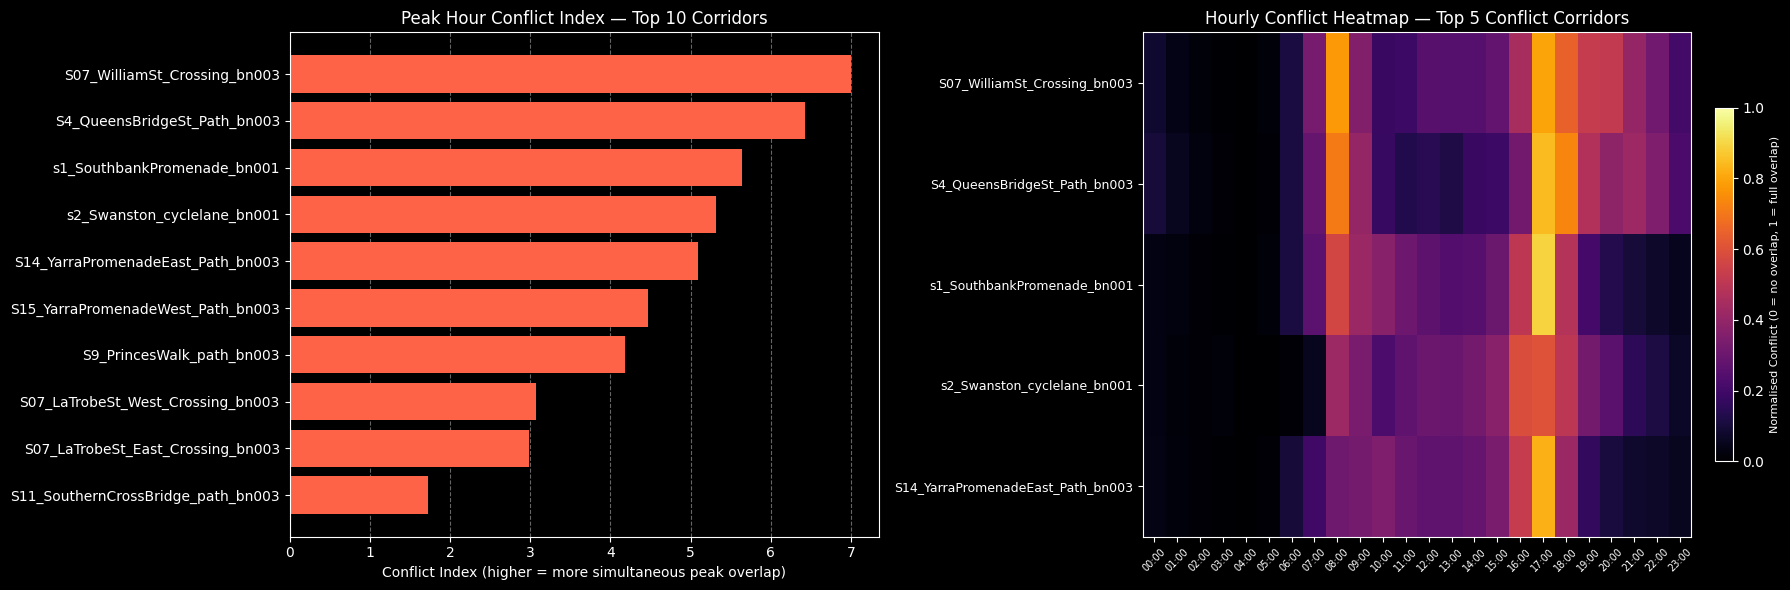

In [15]:
df_top = df_focused[df_focused["countlineName"].isin(top_corridors)].copy()

# Average count per corridor, hour, class
hourly_class = (
    df_top.groupby(["countlineName", df_top["from"].dt.hour, "class"], observed=True)["count"]
    .mean()
    .unstack("class")
    .fillna(0)
)

# Normalise each class within each corridor to [0, 1] so volume differences don't dominate
hourly_norm = hourly_class.groupby("countlineName", observed=True).transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

# Conflict at each hour = min of the two normalised values
hourly_norm["conflict"] = hourly_norm[["cyclist", "pedestrian"]].min(axis=1)

# Aggregate to a single conflict index per corridor
conflict_index = (
    hourly_norm["conflict"]
    .groupby("countlineName")
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"conflict": "conflict_index"})
)

# ---- Plot 1: conflict index ranking ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(conflict_index["countlineName"], conflict_index["conflict_index"], color="tomato")
axes[0].invert_yaxis()
axes[0].set_title("Peak Hour Conflict Index — Top 10 Corridors", fontsize=12)
axes[0].set_xlabel("Conflict Index (higher = more simultaneous peak overlap)")
axes[0].xaxis.grid(True, linestyle="--", alpha=0.4)
axes[0].set_axisbelow(True)

# ---- Plot 2: hourly overlap heatmap for top 5 conflict corridors ----
top5_conflict = conflict_index.head(5)["countlineName"].tolist()

conflict_heatmap = (
    hourly_norm["conflict"]
    .reset_index()
    .rename(columns={"from": "hour"})
)
conflict_heatmap = conflict_heatmap[conflict_heatmap["countlineName"].isin(top5_conflict)]
pivot = conflict_heatmap.pivot(index="countlineName", columns="hour", values="conflict")
pivot = pivot.loc[top5_conflict]  # preserve conflict rank order

im = axes[1].imshow(pivot.values, aspect="auto", cmap="inferno", vmin=0, vmax=1)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index, fontsize=9)
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels([f"{h:02d}:00" for h in pivot.columns], fontsize=7, rotation=45)
axes[1].set_title("Hourly Conflict Heatmap — Top 5 Conflict Corridors", fontsize=12)

cbar = plt.colorbar(im, ax=axes[1], fraction=0.03, pad=0.04)
cbar.set_label("Normalised Conflict (0 = no overlap, 1 = full overlap)", fontsize=8)

plt.tight_layout()
plt.show()

**S07_WilliamSt_Crossing_bn003** and **S4_QueensBridgeSt_Path_bn003** lead the conflict index despite sitting mid-pack on total volume (~0.2–0.3M), meaning they face disproportionately high mode conflict relative to their size. **s1_SouthbankPromenade_bn001** is the standout overall, highest volume in the network by a significant margin and third on conflict. **s2_Swanston_cyclelane_bn001** is notable given its name implies dedicated cycling infrastructure already exists, yet still registers a conflict index above 5.

The heatmap confirms conflict concentrates at the **08:00** and **17:00–18:00** commute windows
across all five corridors, with near-zero overnight. This volume vs conflict divergence is the key
takeaway: raw activity counts alone are insufficient for prioritising infrastructure. William St
and QueensBridge St would be deprioritised under a volume-only lens despite facing the greatest
simultaneous mode pressure.

### 4.5

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>5. Results/Insights</h1>

Discuss any non-trivial result or insight into the problem stemming from your analysis.

<b>Create as many code, markdown and raw cells as needed</b>

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>6. In hindsight...</h1>

In this section (no more than 10 lines) you should reflect on your work and what you have learned. In particular you should include:

<ul>
    <li> a discussion of the most challenging aspect of the data analysis and if/how you overcame the challenge.</li>
    <li> a discussion of any programming technique and/or reference you found particularly useful or helpful for your project.</li>
    <li> an assessment of the outcome of the study in relation to the original goals (i.e., have the goals been reached, or did you have to reassess the goals during the project, and if so why?).</li>
    <li> a discussion of what new, or surprising knowledge or insight into the problem you have gained by conducting the study.</li>
    <li> a discussion of whether you would approach the problem differently if given an opportunity to redo the work, and any advice you would give to someone who would want to work on a similar problem.</li>
    <li> a discussion of how your analysis could be improved or extended in future work.</li>

</ul>